## Analysing the fitted parameters of the Transfer Function.

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Plots_helper import *
from utils.TF_helper import *

INFO       Cache size for target "cython": 1041 MB.
You can call "clear_cache('cython')" to delete all files from the cache or manually delete files in the "/home/ilaria/.cython/brian_extensions" directory. [brian2]


In [4]:
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig) 

In [5]:
from sklearn.decomposition import PCA

In [6]:
neuron_model = 'RS_no_adapt'
fig_name = 'Analysing_TF_fitted_params_RS_no_adapt'

In [7]:
# Load
with open("results_RS_no_adapt_top_10.json", "r") as f:
    data = json.load(f)

# Extract into arrays
alphas = np.array([d["alpha"] for d in data])
errors = np.array([d["mean_error"] for d in data])
poly_params = np.array([d["polynomial_params"] for d in data])  # shape: (n_models, 10)

n_models, n_params = poly_params.shape
print(poly_params.shape)

(10, 10)


### Summary of best 10 parameter sets

In [8]:
params_name = ['P_0', 'P_mu', 'P_sig', 'P_tau', 'P_mu2', 'P_sig2', 'P_tau2', 'P_mu_sig', 'P_mu_tau', 'P_sig_tau']

In [9]:
means = poly_params.mean(axis=0)
stds  = poly_params.std(axis=0)

df_stats = pd.DataFrame({
    "param_id": np.arange(n_params),
    "params_name": params_name,
    "mean": means,
    "std": stds
})

print(df_stats)

   param_id params_name      mean       std
0         0         P_0 -0.050419  0.000239
1         1        P_mu  0.002632  0.000264
2         2       P_sig -0.002401  0.004583
3         3       P_tau -0.002106  0.003419
4         4       P_mu2  0.000965  0.000074
5         5      P_sig2  0.009700  0.006858
6         6      P_tau2 -0.001352  0.010948
7         7    P_mu_sig  0.001321  0.000765
8         8    P_mu_tau -0.000233  0.001469
9         9   P_sig_tau -0.005806  0.004948


In [10]:
### Computing Z-score
poly_z = (poly_params - means) / stds

## Plots

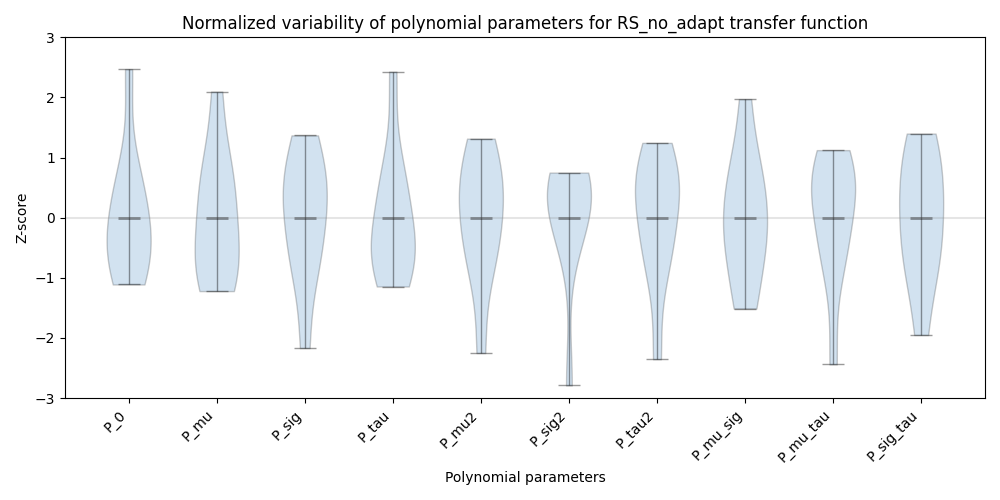

In [11]:
# Violin plot
fig = plot_violin(neuron_model, poly_z, params_name)
figs.append(fig)

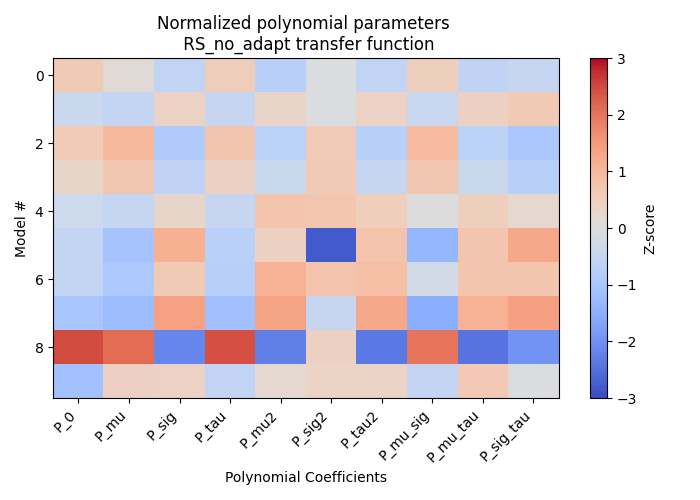

In [12]:
# Heatmap plot
fig = plot_poly_zscore_heatmap(neuron_model, poly_z, params_name)
figs.append(fig)

In [13]:
# Computing correlation with error
corrs = [np.corrcoef(poly_z[:, i], errors)[0,1] for i in range(n_params)]

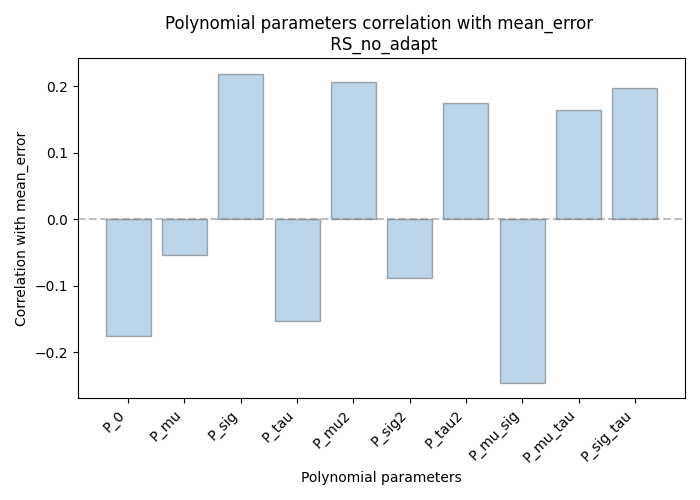

In [14]:
# Correlation between the coefficients and the error
fig = plot_poly_correlation_error(neuron_model, corrs, params_name)
figs.append(fig)

#Positive correlation --> larger parameter values --> larger errors
#Negative correlation --> larger parameter values --> smaller errors
#Correlation close to zero --> no linear relationship with error

In [15]:
# Computing correlation of the parameters between each others
corr_matrix = np.corrcoef(poly_z.T)

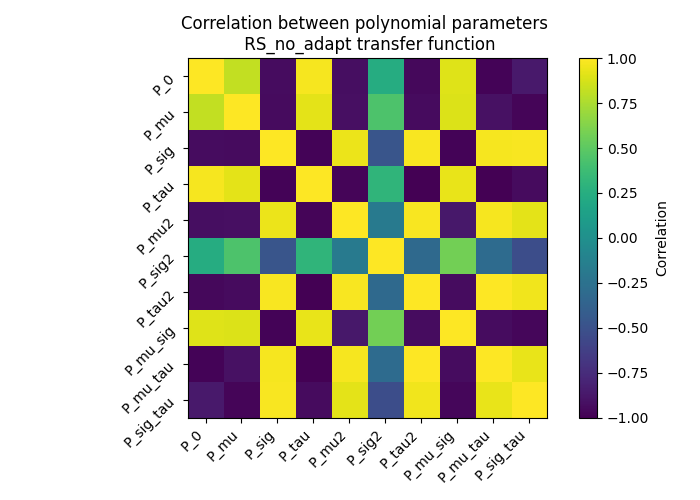

In [16]:
# Correlation between the coefficients
fig = plot_corr_matrix(neuron_model, corr_matrix, params_name)
figs.append(fig)

In [17]:
# TO COMMENT #
####print(f'{params_name[2]},{params_name[4]}, and {params_name[6]} show strong positive correlations with each other.') 
####print(f'{params_name[1]},{params_name[3]}, and {params_name[7]} show similar patterns of negative correlations.') 


In [18]:
### PCA ###
pca = PCA()
X_pca = pca.fit_transform(poly_params)
expl_var = pca.explained_variance_ratio_
cum_var  = np.cumsum(expl_var)

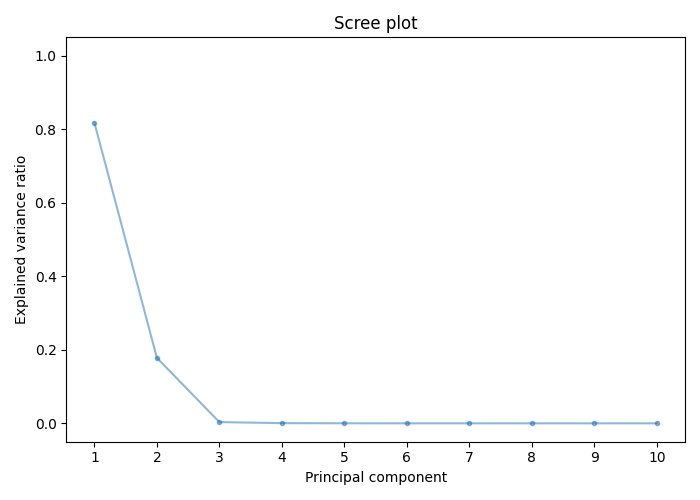

In [19]:
fig = plot_scree(neuron_model, expl_var)
figs.append(fig)

In [20]:
cum_var, expl_var

(array([0.8178154 , 0.99590661, 0.99925889, 0.99983342, 0.99998812,
        0.99999825, 0.99999977, 1.        , 1.        , 1.        ]),
 array([8.17815400e-01, 1.78091211e-01, 3.35227414e-03, 5.74536397e-04,
        1.54698794e-04, 1.01329954e-05, 1.51887424e-06, 2.27298394e-07,
        3.92138100e-10, 5.43145975e-33]))

In [21]:
print(f'PC1 and PC2 explains {((expl_var[0]+expl_var[1]) * 100):.2f}% of the variance!')

PC1 and PC2 explains 99.59% of the variance!


In [22]:
loadings_values = pd.DataFrame(
    pca.components_[:2],   # only PC1 and PC2
    columns=params_name,
    index=['PC1', 'PC2']
)

print(loadings_values)

          P_0      P_mu     P_sig     P_tau     P_mu2    P_sig2    P_tau2  \
PC1  0.016350  0.018567 -0.335753  0.246063 -0.005173  0.235743 -0.792820   
PC2  0.008521  0.000032  0.004127  0.094287 -0.003426 -0.952818 -0.278445   

     P_mu_sig  P_mu_tau  P_sig_tau  
PC1  0.054597 -0.105340  -0.357587  
PC2 -0.016639 -0.041299   0.060268  


In [23]:
for pc in ['PC1', 'PC2']:
    print(f"\nTop contributors to {pc}")
    print(loadings_values.loc[pc].abs().sort_values(ascending=False))



Top contributors to PC1
P_tau2       0.792820
P_sig_tau    0.357587
P_sig        0.335753
P_tau        0.246063
P_sig2       0.235743
P_mu_tau     0.105340
P_mu_sig     0.054597
P_mu         0.018567
P_0          0.016350
P_mu2        0.005173
Name: PC1, dtype: float64

Top contributors to PC2
P_sig2       0.952818
P_tau2       0.278445
P_tau        0.094287
P_sig_tau    0.060268
P_mu_tau     0.041299
P_mu_sig     0.016639
P_0          0.008521
P_sig        0.004127
P_mu2        0.003426
P_mu         0.000032
Name: PC2, dtype: float64


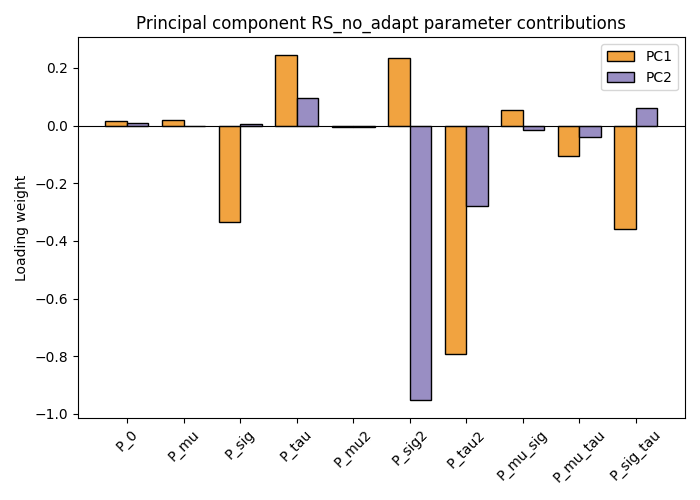

In [24]:
pc1 = loadings_values.loc['PC1']
pc2 = loadings_values.loc['PC2']

fig = plot_pca_parameter_contributions(neuron_model, pc1, pc2)
figs.append(fig)

In [25]:
# PCA biplot
loadings = pca.components_

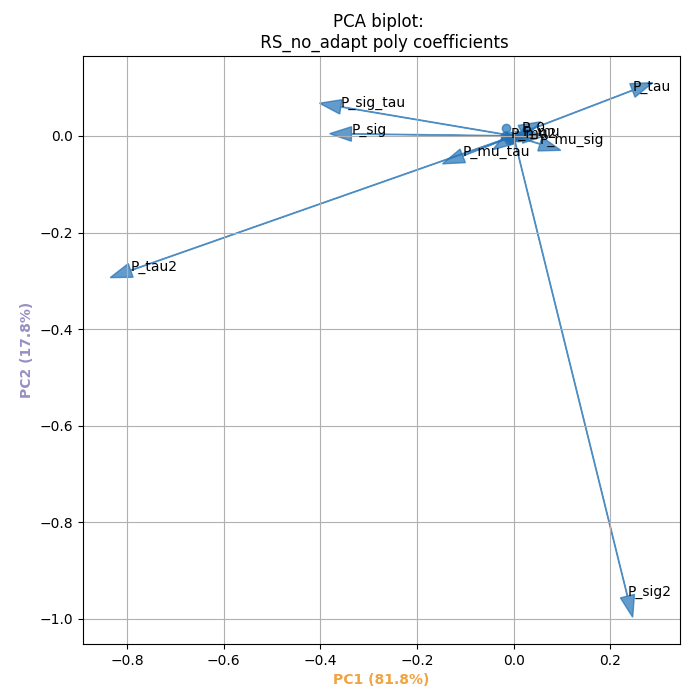

In [26]:
fig = plot_pca_biplot(neuron_model, params_name, X_pca, loadings, expl_var)
figs.append(fig)

## Testing distribution mean error as a function of alpha. Best #10

In [27]:
data_folder = '../../neuron_models/AdEx'
idx = 0 # in this case only one model per cell type is provided

params_SI = get_params_model_SI(neuron_model = neuron_model,
                             json_file_name = os.path.join(data_folder, neuron_model + '.json'))

In [28]:
network_config_folder = '../../config/'
network_file_name = 'network_config_file_v0.json'

network_config = get_network_config(json_file_name =  os.path.join(network_config_folder, network_file_name))

params_SI = adding_K_params(neuron_params = params_SI,
                            network_config = network_config)

In [29]:
simulation_folder = '../data_extraction/simulations/TF_RS_no_adapt_v1'
# --- Load the data ---
df_RS = pd.read_csv(
    os.path.join(simulation_folder, 'testing_TF_data_RS.dat'),
    delim_whitespace = True,
    header = 0
)
x_s = sorted(df_RS['input_exc'].unique())
y_s = sorted(df_RS['input_inh'].unique())
df_RS_slice_array_std = df_RS['std_f_out'].to_numpy().reshape(len(y_s), len(x_s))

Mask = True

# min and max freq of the excitatory and inhibitory external input
min_freq = 0
max_freq = 20
if Mask == True:
    # Define range
    x_s = np.array(x_s)
    y_s = np.array(y_s)
    
  
    x_mask = (x_s >= min_freq) & (x_s <= max_freq)
    y_mask = (x_s >= min_freq) & (x_s <= max_freq)
    
    x_s_sel = x_s[x_mask]
    y_s_sel = y_s[y_mask]
    
    # Filter dataframe
    df_sel = df_RS[
        (df_RS['input_exc'] >= min_freq) & (df_RS['input_exc'] <= max_freq) &
        (df_RS['input_inh'] >= min_freq) & (df_RS['input_inh'] <= max_freq)
    ]
    
    # Pivot to 2D grid
    df_RS_slice_array_masked = (
        df_sel
        .pivot(index='input_inh', columns='input_exc', values='avg_f_out')
        .loc[y_s_sel, x_s_sel]
        .to_numpy()
    )

    df_RS_slice_array_std_masked = (
        df_sel
        .pivot(index='input_inh', columns='input_exc', values='std_f_out')
        .loc[y_s_sel, x_s_sel]
        .to_numpy()
    )
    inh_vals = y_s_sel
    df_RS = df_sel
    df_RS_slice_array_std = df_RS_slice_array_std_masked


In [30]:
for alpha_idx in range(0, len(alphas)):
    df_RS[f'fit_rate_alpha_{alpha_idx}'] = TF_template(
    data=df_RS, params=params_SI,
    poly_params=poly_params[alpha_idx], alpha=alphas[alpha_idx]
    )
    
unique_inh = np.sort(df_RS['input_inh'].unique())
colors = cm.viridis(np.linspace(0, 1, len(unique_inh)))

In [31]:
#df_RS

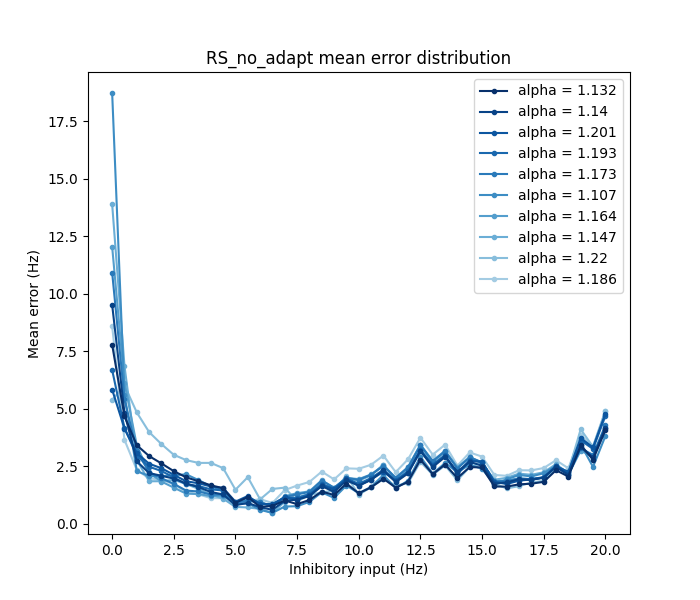

In [32]:
fig = plt.figure(figsize=(7,6))
for alpha_idx in reversed(range(0, len(alphas))):
    distr_mean_error = get_mean_error_distribution(neuron_model, df_RS,
                                                   poly_params[alpha_idx], params_SI,
                                                   alphas[alpha_idx],
                                                   unique_inh,
                                                   alpha_idx = alpha_idx)
    
    fig = plots_TF_distr_mean_error(neuron_model, inh_vals, distr_mean_error,
                                    alpha = alphas[alpha_idx], alpha_idx = alpha_idx, fig = fig)


In [33]:
save_figs(fig_path, fig_name, figs)